In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ankurpaul52/balanced-multi-crop-plant-disease-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/balanced-multi-crop-plant-disease-dataset


In [31]:
import os
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch.nn as nn
from tqdm import trange
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
sns.set()

In [3]:
os.listdir("/kaggle/input/balanced-multi-crop-plant-disease-dataset")

['datasets']

In [4]:
os.listdir("/kaggle/input/balanced-multi-crop-plant-disease-dataset/datasets")

['tomato', 'peanut', 'corn', 'grape', 'mango']

In [5]:
os.listdir("/kaggle/input/balanced-multi-crop-plant-disease-dataset/datasets/grape")

['Grape___healthy', 'Grape___Esca', 'Grape___Leaf_blight', 'Grape___Black_rot']

In [6]:
data_dir = "/kaggle/input/balanced-multi-crop-plant-disease-dataset/datasets/grape"

In [7]:
train_ratio = 0.7
valid_ratio = 0.15
test_ratio = 0.15

In [8]:
train_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [9]:
val_test_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [10]:
full_dataset = ImageFolder(data_dir, transform = train_transforms)

In [11]:
targets = np.array(full_dataset.targets)

In [12]:
targets[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [13]:
train_idx, temp_idx, _, temp_targets = train_test_split(
    np.arange(len(targets)),
    targets,
    stratify = targets,
    test_size = (1 - train_ratio),
    random_state = 101
)

In [14]:
valid_ratio_adjusted = valid_ratio / (valid_ratio + test_ratio)
valid_idx, test_idx = train_test_split(
    temp_idx,
    stratify = temp_targets,
    test_size = (1 - valid_ratio_adjusted),
    random_state = 101
)

In [15]:
train_dataset = Subset(full_dataset, train_idx)
valid_dataset = Subset(full_dataset, valid_idx)
test_dataset = Subset(full_dataset, test_idx)

In [16]:
valid_dataset.dataset.transform = val_test_transforms
test_dataset.dataset.transform = val_test_transforms

In [17]:
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True, num_workers = 4)
valid_loader = DataLoader(valid_dataset, batch_size = 32, shuffle = False, num_workers = 4)
test_loader = DataLoader(test_dataset, batch_size = 32, shuffle = False, num_workers = 4)

In [18]:
print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(valid_dataset)}")
print(f"Test set size: {len(test_dataset)}")
print(f"Classes: {full_dataset.classes}")
print(f"Number of classes: {len(full_dataset.classes)}")

Training set size: 3359
Validation set size: 720
Test set size: 721
Classes: ['Grape___Black_rot', 'Grape___Esca', 'Grape___Leaf_blight', 'Grape___healthy']
Number of classes: 4


In [19]:
num_classes = len(full_dataset.classes)

In [20]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [21]:
def plot_results(train_losses, train_accs, valid_losses, valid_accs):
    fig, axes = plt.subplots(1, 2, figsize = (15, 5))
    xs = np.arange(1, len(train_losses) + 1, 1)
    axes[0].plot(xs, train_losses, label = "Training Loss")
    axes[0].plot(xs, valid_losses, label = "Validation Loss")
    axes[0].set_title("Training loss vs Validation loss", fontsize = 15)
    axes[0].set_xlabel("Epochs", fontsize = 10)
    axes[0].set_ylabel("Loss", fontsize = 10)
    axes[0].set_xticks(xs)
    axes[0].legend()
    axes[1].plot(xs, train_accs, label = "Training Accuracy")
    axes[1].plot(xs, valid_accs, label = "Validation Accuracy")
    axes[1].set_title("Training accuracy vs Validation accuracy", fontsize = 15)
    axes[1].set_xlabel("Epoch", fontsize = 10)
    axes[1].set_ylabel("Accuracy", fontsize = 10)
    axes[1].set_xticks(xs)
    axes[1].legend()
    plt.tight_layout()
    plt.show()

In [22]:
def train_step(model, criterion, optimizer, dataloader, device = device):
    model.train()
    total_loss = 0
    total_acc = 0
    for x, y in dataloader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        preds = model(x)
        loss = criterion(preds, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        total_acc += (preds.argmax(1) == y).type(torch.float).sum().item()
    return total_loss / len(dataloader), 100 * total_acc / len(dataloader.dataset)

In [23]:
def valid_step(model, criterion, dataloader, device = device):
    model.eval()
    total_loss = 0
    total_acc = 0
    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            preds = model(x)
            total_loss += criterion(preds, y).item()
            total_acc += (preds.argmax(1) == y).type(torch.float).sum().item()
    return total_loss / len(dataloader), 100 * total_acc / len(dataloader.dataset)

In [24]:
def train_model(model, n_epochs, optimizer, train_loader, valid_loader, device = device):
    train_losses, valid_losses = [], []
    train_accs, valid_accs = [], []
    criterion = nn.CrossEntropyLoss()
    pbar = trange(n_epochs)
    for epoch in pbar:
        train_loss, train_acc = train_step(model, criterion, optimizer, train_loader, device = device)
        valid_loss, valid_acc = valid_step(model, criterion, valid_loader, device = device)
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        valid_losses.append(valid_loss)
        valid_accs.append(valid_acc)
        pbar.set_description(f"Train Loss: {train_loss:.3f} | Valid Loss: {valid_loss:.3f} | Train Acc: {train_acc:.3f} | Valid Acc: {valid_acc:.3f}")
    plot_results(train_losses, train_accs, valid_losses, valid_accs)
    return {'train_acc': train_acc, 'train_loss': train_loss, 'valid_acc': valid_acc, 'valid_loss': valid_loss}

In [25]:
class CNN1(nn.Module):
    def __init__(self, num_classes):
        super(CNN1, self).__init__()
        self.network = nn.Sequential(
            nn.Conv2d(in_channels = 3, out_channels = 256, kernel_size = 3, stride = 1, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2),
            
            nn.Conv2d(in_channels = 256, out_channels = 128, kernel_size = 3, stride = 1, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2),
            
            nn.Conv2d(in_channels = 128, out_channels = 64, kernel_size = 3, stride = 1, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2),

            nn.Flatten(),

            nn.Linear(16 * 16 * 64, 256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.network(x)

Train Loss: 0.101 | Valid Loss: 0.176 | Train Acc: 96.963 | Valid Acc: 93.750: 100%|██████████| 10/10 [01:37<00:00,  9.71s/it]


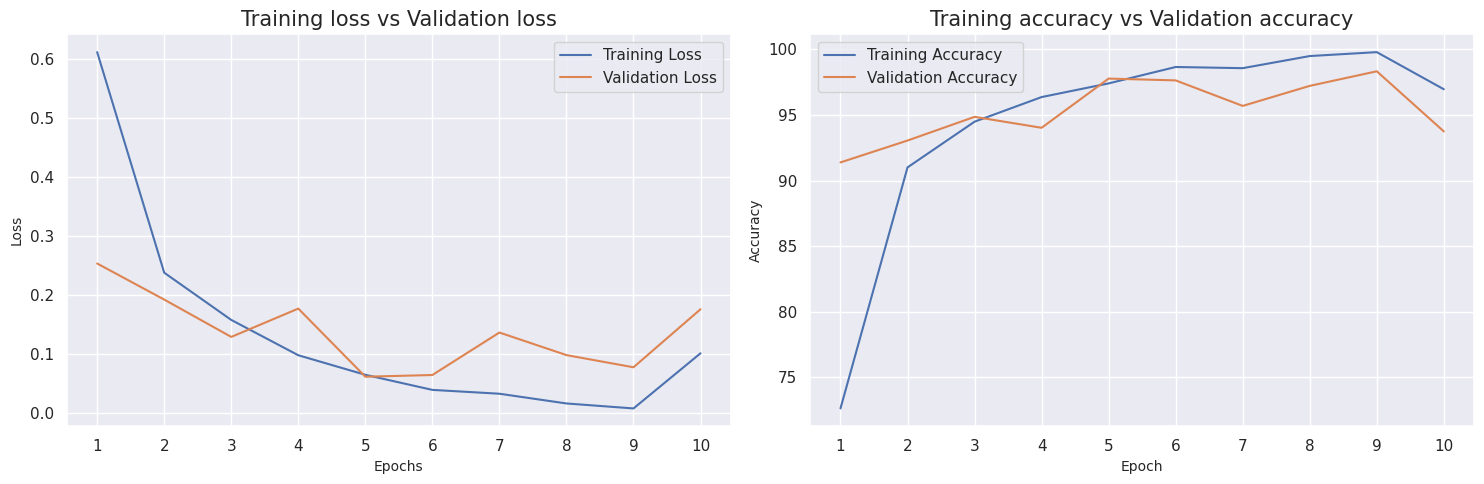

In [26]:
cnn_model1 = CNN1(num_classes = num_classes).to(device)
optimizer = optim.Adam(cnn_model1.parameters(), lr = 0.001)
results = train_model(cnn_model1, 10, optimizer, train_loader, valid_loader, device = device)

In [29]:
cnn_model1.eval()
criterion = nn.CrossEntropyLoss()
total_loss = 0
total_acc = 0
pred_label, truth_label = [], []
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        preds = cnn_model1(x)
        total_loss += criterion(preds, y).item()
        total_acc += (preds.argmax(1) == y).type(torch.float).sum().item()
        pred_label.extend(preds.argmax(1).cpu().numpy())
        truth_label.extend(y.cpu().numpy())
print(f"Test Loss: {total_loss / len(test_loader)}")
print(f"Test Accuracy: {100 * total_acc / len(test_loader.dataset)}")

Test Loss: 0.2519943387774022
Test Accuracy: 92.37170596393898


In [32]:
print(classification_report(truth_label, pred_label))

              precision    recall  f1-score   support

           0       0.94      0.83      0.88       180
           1       0.88      0.96      0.92       180
           2       0.96      0.91      0.93       180
           3       0.92      1.00      0.96       181

    accuracy                           0.92       721
   macro avg       0.93      0.92      0.92       721
weighted avg       0.93      0.92      0.92       721



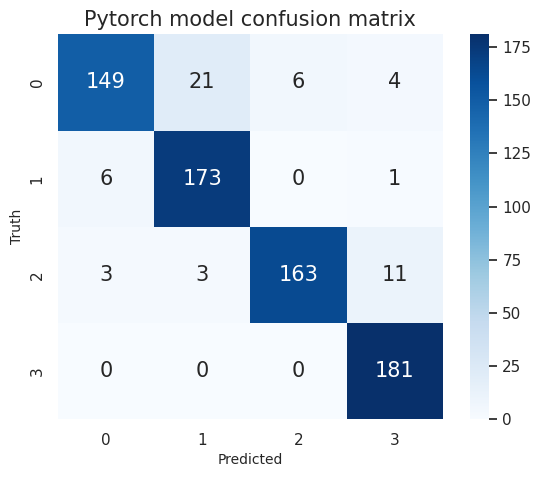

In [33]:
plt.figure(figsize = (7, 5))
sns.heatmap(confusion_matrix(truth_label, pred_label), annot = True, square = True, cbar = True, annot_kws = {'size': 15}, fmt = 'd', cmap = 'Blues')
plt.title("Pytorch model confusion matrix", fontsize = 15)
plt.xlabel("Predicted", fontsize = 10)
plt.ylabel("Truth", fontsize = 10)
plt.show()

In [59]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Input, Conv2D, MaxPooling2D, BatchNormalization, Dropout, ReLU, Flatten, Dense
from keras.callbacks import EarlyStopping

In [38]:
data = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    image_size = (128, 128),
    batch_size = 32,
    shuffle = True,
    seed = 123
)

Found 4800 files belonging to 4 classes.


In [39]:
total_batches = tf.data.experimental.cardinality(data).numpy()
print(f"Total batches: {total_batches}")

Total batches: 150


In [44]:
def train_test_val_split(dataset):
    train_size = int(total_batches * 0.7)
    valid_size = int(total_batches * 0.15)
    test_size = int(total_batches * 0.15)

    train_data = dataset.take(train_size)
    valid_data = dataset.skip(train_size).take(valid_size)
    test_data = dataset.skip(train_size + valid_size).take(test_size)

    return train_data, valid_data, test_data

In [45]:
train_data, valid_data, test_data = train_test_val_split(data)

In [46]:
print(f"Number of Training batches: {len(train_data)}")
print(f"Number of Validation batches: {len(valid_data)}")
print(f"Number of Test batches: {len(valid_data)}")

Number of Training batches: 105
Number of Validation batches: 22
Number of Test batches: 22


In [47]:
def normalize_img(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

In [50]:
train_ds = train_data.map(normalize_img)
valid_ds = valid_data.map(normalize_img)
test_ds = test_data.map(normalize_img)

In [63]:
tf_model = Sequential()

In [64]:
tf_model.add(Input(shape = (128, 128, 3)))

tf_model.add(Conv2D(256, (3, 3), padding = 'same'))
tf_model.add(ReLU())
tf_model.add(MaxPooling2D(pool_size = (2, 2)))
tf_model.add(Dropout(0.25))

tf_model.add(Conv2D(128, (3, 3), padding = 'same'))
tf_model.add(ReLU())
tf_model.add(MaxPooling2D(pool_size = (2, 2)))
tf_model.add(Dropout(0.25))

tf_model.add(Conv2D(64, (3, 3), padding = 'same'))
tf_model.add(ReLU())
tf_model.add(MaxPooling2D(pool_size = (2, 2)))
tf_model.add(Dropout(0.10))

tf_model.add(Flatten())

tf_model.add(Dense(256, activation = 'relu'))
tf_model.add(Dense(128, activation = 'relu'))
tf_model.add(Dense(64, activation = 'relu'))
tf_model.add(Dense(num_classes, activation = 'softmax'))

In [65]:
tf_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 256)  │         7,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 128, 128, 256)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64, 64, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,611,972 (17.59 MB)

 Trainable params: 4,611,972 (17.59 MB)

 Non-trainable params: 0 (0.00 B)

In [66]:
tf_model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate = 0.001),
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits = True),
    metrics = ['accuracy']
)

In [67]:
early_stopping = EarlyStopping(monitor = 'val_loss', patience = 2)

In [68]:
history = tf_model.fit(train_ds, validation_data = valid_ds, epochs = 20, callbacks = [early_stopping])

Epoch 1/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 20s 132ms/step - accuracy: 0.4099 - loss: 1.1557 - val_accuracy: 0.7301 - val_loss: 0.5999
Epoch 2/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 11s 109ms/step - accuracy: 0.7629 - loss: 0.5214 - val_accuracy: 0.9077 - val_loss: 0.2838
Epoch 3/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 11s 107ms/step - accuracy: 0.8763 - loss: 0.3094 - val_accuracy: 0.8906 - val_loss: 0.3170
Epoch 4/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 11s 105ms/step - accuracy: 0.9274 - loss: 0.1960 - val_accuracy: 0.9318 - val_loss: 0.1779
Epoch 5/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 11s 100ms/step - accuracy: 0.9457 - loss: 0.1495 - val_accuracy: 0.9531 - val_loss: 0.1231
Epoch 6/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 11s 101ms/step - accuracy: 0.9495 - loss: 0.1308 - val_accuracy: 0.9659 - val_loss: 0.1010
Epoch 7/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 11s 102ms/step - accuracy: 0.9655 - loss: 0.0968 - val_accuracy: 0.9446 - val_loss: 0.1245
Epoch 8/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 11s 105ms/step - accuracy: 0.9730 - loss: 0

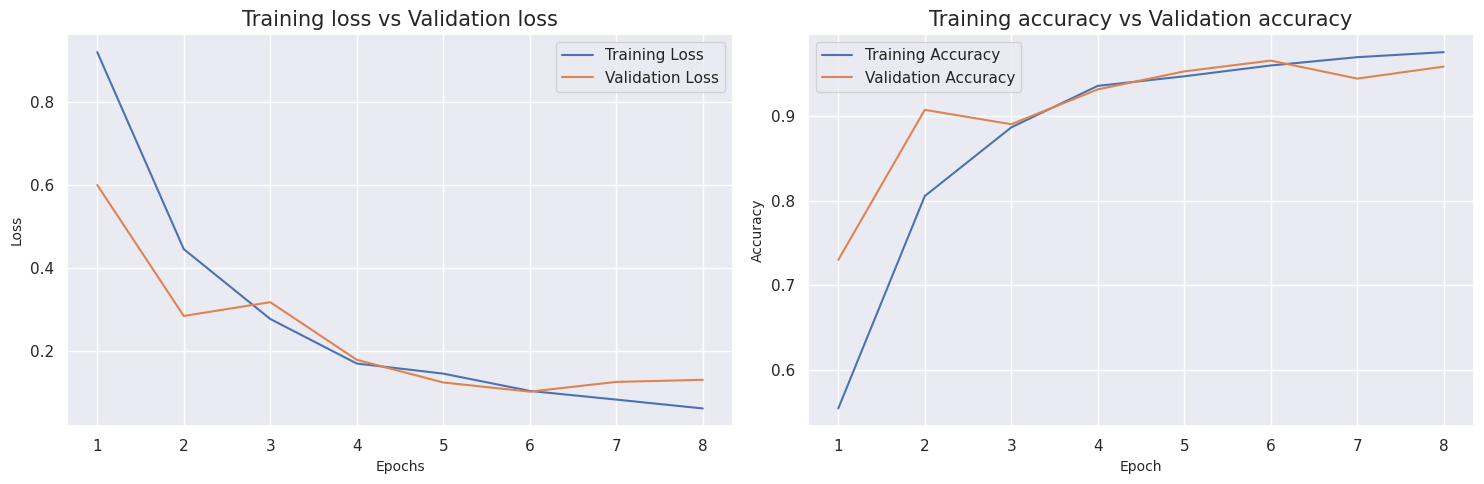

In [69]:
plot_results(history.history['loss'], history.history['accuracy'], history.history['val_loss'], history.history['val_accuracy'])

In [70]:
tf_model.evaluate(test_ds)

22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9562 - loss: 0.1202


[0.1134212464094162, 0.9559659361839294]